In [15]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
from scipy.stats import pearsonr
import sys
sys.path.insert(0,'..')
from scripts.models.pod.model import RampPOD
warnings.filterwarnings('ignore')
pplt.rc.update({
    'tick.minor':False,
    'savefig.dpi':300,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'legend.fontsize':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal'})

In [2]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
PREDSDIR   = CONFIGS['filepaths']['predictions']
MODELSDIR  = CONFIGS['filepaths']['models']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELS     = CONFIGS['experiments']
NNCONFIG   = MODELS['nn']
SRCONFIG   = MODELS['sr']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
YEARS      = list(range(2000, 2021))

In [16]:
import numpy as np
import pandas as pd

url = "https://psl.noaa.gov/data/correlation/nina34.anom.data"

raw = pd.read_csv(
    url,
    sep=r"\s+",
    header=None,
    skiprows=1,
    engine="python",
)

# keep only year + 12 months, numeric only
raw = raw[pd.to_numeric(raw[0], errors="coerce").notna()]
raw = raw.iloc[:, :13].apply(pd.to_numeric, errors="coerce")

nino = {}
for _, row in raw.iterrows():
    year = int(row[0])
    if 2000 <= year <= 2020:
        # Jun, Jul, Aug = indices 6,7,8
        jja = np.nanmean(row[[6, 7, 8]].to_numpy())
        if np.isfinite(jja):
            nino[year] = float(jja)

print({k: round(v, 2) for k, v in sorted(nino.items())})

{2000: -0.65, 2001: -0.09, 2002: 0.78, 2003: 0.06, 2004: 0.46, 2005: -0.08, 2006: 0.11, 2007: -0.55, 2008: -0.37, 2009: 0.45, 2010: -1.05, 2011: -0.49, 2012: 0.25, 2013: -0.4, 2014: 0.05, 2015: 1.52, 2016: -0.36, 2017: 0.14, 2018: 0.08, 2019: 0.28, 2020: -0.41}


In [17]:
def load_all_splits(var):
    pieces = []
    for split in ['train','valid','test']:
        path = os.path.join(SPLITSDIR,f'{split}.h5')
        with xr.open_dataset(path,engine='h5netcdf') as ds:
            if var in ds:
                pieces.append(ds[var].load())
    if not pieces:
        raise KeyError(f'{var!r} not found in any split file')
    return xr.concat(pieces,dim='time')

def annual_q99(da,years):
    slices = []
    for yr in years:
        mask = da.time.dt.year == yr
        if not mask.any():
            continue
        q = da.sel(time=mask).quantile(0.99,dim='time',skipna=True)
        if 'quantile' in q.coords:
            q = q.drop_vars('quantile')
        slices.append(q.expand_dims(year=[yr]))
    return xr.concat(slices,dim='year')

def pearson_map(q99da,nino_dict):
    years = q99da.year.values
    nino  = np.array([nino_dict.get(int(y),np.nan) for y in years],dtype=float)
    q99v  = q99da.values.astype(float)
    nlat,nlon = q99v.shape[1],q99v.shape[2]
    r_map = np.full((nlat,nlon),np.nan)
    p_map = np.full((nlat,nlon),np.nan)
    for i in range(nlat):
        for j in range(nlon):
            vals = q99v[:,i,j]
            ok   = np.isfinite(vals) & np.isfinite(nino)
            if ok.sum() >= 5:
                r_map[i,j],p_map[i,j] = pearsonr(nino[ok],vals[ok])
    coords = {'lat':q99da.lat,'lon':q99da.lon}
    return (xr.DataArray(r_map,dims=['lat','lon'],coords=coords),
            xr.DataArray(p_map,dims=['lat','lon'],coords=coords))

# --- copied verbatim from mapping.ipynb ---
def flatten(a,b):
    a,b  = a.values.ravel(),b.values.ravel()
    mask = np.isfinite(a) & np.isfinite(b)
    return a[mask],b[mask]

def fit_empirical_qm(a,b,nquantiles=2000,eps=1e-8):
    apos,bpos = a[a>0],b[b>0]
    quantiles = np.linspace(0,1,nquantiles)
    aq = np.quantile(apos,quantiles) if len(apos)>0 else np.array([0.])
    bq = np.quantile(bpos,quantiles) if len(bpos)>0 else np.array([0.])
    aq = np.maximum.accumulate(aq)
    bq = np.maximum.accumulate(bq)
    def qm(x):
        x   = np.maximum(np.asarray(x,float),0)
        out = np.zeros_like(x)
        out[x>0] = np.interp(x[x>0],aq,bq,left=bq[0],right=bq[-1])
        return out
    return qm

# --- copied verbatim from results.ipynb ---
def _load_kernel_weights(weightsfrom):
    wlist = []
    for seed in NNCONFIG['seeds']:
        wpath = os.path.join(WEIGHTSDIR,f'{weightsfrom}_{seed}_weights.nc')
        with xr.open_dataset(wpath,engine='h5netcdf') as wds:
            wlist.append(wds['k'].load())
    return xr.concat(wlist,dim='seed').mean('seed')

def _kernel_integrate_fields(fieldvars,splitvars,weightsmean):
    dsig   = splitvars['dsig'].values
    result = {}
    for var in fieldvars:
        da        = splitvars[var]
        spacedims = [d for d in da.dims if d != 'sig']
        arr       = da.transpose(*spacedims,'sig').values
        w         = weightsmean.sel(field=var).values
        integ     = (arr.reshape(-1,arr.shape[-1])*w[None,:]*dsig[None,:]).sum(axis=1)
        coords    = {d:da.coords[d] for d in spacedims if d in da.coords}
        result[var] = xr.DataArray(integ.reshape(arr.shape[:-1]),dims=spacedims,coords=coords)
    return result

def eval_nn_allyears(name,runconfig):
    """
    Return (time, lat, lon) ERA5-mm predictions across all 3 splits, seed-averaged.
    Loads pre-computed prediction files when present; runs inline NN inference otherwise.
    """
    import torch
    from scripts.models.nn.classes.factory import build_model
    from scripts.models.nn.classes.dataset import FieldDataset,load_split
    from scripts.models.nn.classes.inferencer import Inferencer

    fieldvars = runconfig['fieldvars']
    localvars = runconfig.get('localvars',[])
    haskernel = runconfig['kind'] != 'baseline'
    seeds     = NNCONFIG['seeds']
    device    = 'cuda' if torch.cuda.is_available() else 'cpu'

    with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
        stats = json.load(f)

    pieces = []
    for split in ['train','valid','test']:
        fpath = os.path.join(PREDSDIR,f'{name}_{split}_predictions.nc')
        if os.path.exists(fpath):
            with xr.open_dataset(fpath) as ds:
                pred = ds['tp'].load()
                if 'seed' in pred.dims:
                    pred = pred.mean('seed')
                pieces.append(pred)
            continue

        print(f'  {name}: evaluating {split} inline on {device}...')
        fields,local,pr,dsig,nlevs,valid,refda = load_split(
            split,fieldvars,localvars,SPLITSDIR,targetvar='tp')
        dataset    = FieldDataset(fields,local,pr,dsig)
        dataloader = torch.utils.data.DataLoader(
            dataset,batch_size=NNCONFIG['batchsize'],shuffle=False,num_workers=0)

        seed_preds = []
        for seed in seeds:
            ckpt = os.path.join(MODELSDIR,'nn',f'{name}_{seed}.pth')
            if not os.path.exists(ckpt):
                print(f'  Checkpoint not found: {ckpt}')
                return None
            model = build_model(name,runconfig,nlevs)
            model.load_state_dict(torch.load(ckpt,map_location='cpu'))
            inferencer = Inferencer(model.to(device),dataloader,device)
            preds,_ = inferencer.predict(haskernel)
            seed_preds.append(preds)
            del model,inferencer

        flat_avg = np.mean(seed_preds,axis=0)
        grid = np.full(valid.shape,np.nan,dtype=np.float32)
        grid[valid] = flat_avg
        native = np.maximum(
            np.expm1(grid*stats['tp_std']+stats['tp_mean']),0.0
        ).reshape(refda.shape)
        pieces.append(xr.DataArray(native,dims=refda.dims,coords=refda.coords))

    if not pieces:
        return None
    return xr.concat(pieces,dim='time')

In [18]:
# Fit QM function on train+valid ERA5 tp -> IMERG pr
train_ds = xr.open_dataset(os.path.join(SPLITSDIR,'train.h5'),engine='h5netcdf')[['tp','pr']].load()
valid_ds = xr.open_dataset(os.path.join(SPLITSDIR,'valid.h5'),engine='h5netcdf')[['tp','pr']].load()
era5  = xr.concat([train_ds.tp,valid_ds.tp],dim='time')
imerg = xr.concat([train_ds.pr,valid_ds.pr],dim='time')
era5,imerg = xr.align(era5,imerg,join='inner')
era5flat,imergflat = flatten(era5,imerg)
qmfn = fit_empirical_qm(era5flat,imergflat)
del train_ds,valid_ds,era5,imerg,era5flat,imergflat
print('QM function fitted.')

QM function fitted.


In [19]:
# IMERG is the reference; no QM needed
imerg_all = load_all_splits('pr')
q99_imerg = annual_q99(imerg_all,YEARS)
r_imerg,p_imerg = pearson_map(q99_imerg,nino)
del imerg_all,q99_imerg
print('IMERG done. r range:',float(r_imerg.min()),'to',float(r_imerg.max()))

IMERG done. r range: -0.7067736661912438 to 0.6542809401489583


In [20]:
# B_L-based POD ramp model
bl = load_all_splits('bl')
if 'sig' in bl.dims:
    bl = bl.mean('sig')
with np.load(os.path.join(MODELSDIR,'pod','pod_bl.npz')) as d:
    pod = RampPOD(float(d['alpha']),float(d['xcrit']))
bl_pred_np = pod.forward(bl)
bl_pred    = xr.DataArray(bl_pred_np.reshape(bl.shape),dims=bl.dims,coords=bl.coords)
bl_qm      = xr.apply_ufunc(qmfn,bl_pred,vectorize=False)
q99_bl     = annual_q99(bl_qm,YEARS)
r_bl,p_bl  = pearson_map(q99_bl,nino)
del bl,bl_pred,bl_pred_np,bl_qm,q99_bl
print('POD (B_L) done. r range:',float(r_bl.min()),'to',float(r_bl.max()))

POD (B_L) done. r range: -0.696607905076568 to 0.6430675791611128


In [22]:
# Baseline NN: base_rh_shf_lhf (all splits; loads files if present, else evaluates inline)
# Note: train-split predictions are in-sample.
run_base = 'base_all'
base_all = eval_nn_allyears(run_base,NNCONFIG['runs'][run_base])
if base_all is not None:
    base_qm  = xr.apply_ufunc(qmfn,base_all,vectorize=False)
    q99_base = annual_q99(base_qm,YEARS)
    r_base,p_base = pearson_map(q99_base,nino)
    del base_all,base_qm,q99_base
    print('Baseline NN done. r range:',float(r_base.min()),'to',float(r_base.max()))
else:
    r_base,p_base = None,None
    print('Baseline NN skipped (checkpoints not found)')

  base_all: evaluating train inline on cuda...
  base_all: evaluating test inline on cuda...
Baseline NN done. r range: -0.6714668618582575 to 0.5989896340049212


In [23]:
# Parametric kernel NN: param_gauss_all (all splits; loads files if present, else evaluates inline)
# Note: train-split predictions are in-sample.
run_param = 'param_gauss_all'
param_all = eval_nn_allyears(run_param,NNCONFIG['runs'][run_param])
if param_all is not None:
    param_qm  = xr.apply_ufunc(qmfn,param_all,vectorize=False)
    q99_param = annual_q99(param_qm,YEARS)
    r_param,p_param = pearson_map(q99_param,nino)
    del param_all,param_qm,q99_param
    print('Kernel NN done. r range:',float(r_param.min()),'to',float(r_param.max()))
else:
    r_param,p_param = None,None
    print('Kernel NN skipped (checkpoints not found)')

  param_gauss_all: evaluating train inline on cuda...
  param_gauss_all: evaluating test inline on cuda...
Kernel NN done. r range: -0.739258881078791 to 0.6255952082173092


In [29]:
# SR equation (complexity 9), evaluated directly on all splits

srrc        = SRCONFIG["runs"]["sr_gauss_all"]
fieldvars   = list(srrc["fieldvars"])
localvars   = list(srrc.get("localvars", []))
weightsfrom = srrc["weightsfrom"]

# -----------------------------
# Concatenate normalized splits
# -----------------------------
pieces_norm = []

for split in ["train", "valid", "test"]:
    normpath = os.path.join(SPLITSDIR, f"norm_{split}.h5")
    with xr.open_dataset(normpath, engine="h5netcdf") as ds:
        pieces_norm.append({v: ds[v].load() for v in ds.data_vars})

all_vars = sorted(set().union(*[set(p.keys()) for p in pieces_norm]))

svars = {
    v: xr.concat([p[v] for p in pieces_norm if v in p], dim="time")
    for v in all_vars
}

# Add dsig if missing from normalized files
if "dsig" not in svars:
    with xr.open_dataset(os.path.join(SPLITSDIR, "train.h5"), engine="h5netcdf") as ds:
        svars["dsig"] = ds["dsig"].load()

# -----------------------------
# Kernel-integrate field variables
# -----------------------------
def kernel_integrate_fields(fieldvars, splitvars, weightsmean):
    dsig_da = splitvars["dsig"]
    result = {}

    for var in fieldvars:
        da = splitvars[var]

        spacedims = [d for d in da.dims if d != "sig"]
        arr = da.transpose(*spacedims, "sig").values

        wda = weightsmean.loc[dict(field=var)]
        w = wda.transpose("sig").values

        dsig_v = dsig_da

        if "field" in dsig_v.dims:
            dsig_v = dsig_v.loc[dict(field=var)]

        extra_dsig_dims = [d for d in dsig_v.dims if d != "sig"]
        if extra_dsig_dims:
            dsig_v = dsig_v.mean(dim=extra_dsig_dims)

        dsig = dsig_v.transpose("sig").values

        integ = (
            arr.reshape(-1, arr.shape[-1])
            * w[None, :]
            * dsig[None, :]
        ).sum(axis=1)

        coords = {d: da.coords[d] for d in spacedims if d in da.coords}

        result[var] = xr.DataArray(
            integ.reshape(arr.shape[:-1]),
            dims=spacedims,
            coords=coords,
            name=var,
        )

        print(f"{var}: integrated {arr.shape} -> {result[var].shape}")

    return result


wmean = _load_kernel_weights(weightsfrom)

print("fieldvars:", fieldvars)
print("weight fields:", list(wmean.field.values))

integ = kernel_integrate_fields(fieldvars, svars, wmean)

# -----------------------------
# Build eval namespace
# -----------------------------
refda = svars["tp"]

ns = {
    "Abs": np.abs,
    "abs": np.abs,
    "sqrt": np.sqrt,
    "exp": np.exp,
    "log": np.log,
    "sin": np.sin,
    "cos": np.cos,
    "__builtins__": {},
}

for v, da in integ.items():
    da = da.transpose("time", "lat", "lon")
    ns[v] = da.values.ravel()

for v in localvars:
    if v not in svars:
        print(f"Skipping missing localvar: {v}")
        continue

    da = svars[v]
    extra_dims = [d for d in da.dims if d not in ("time", "lat", "lon")]

    if extra_dims:
        da = da.mean(dim=extra_dims)

    da = da.transpose("time", "lat", "lon")
    ns[v] = da.values.ravel()

# -----------------------------
# Load complexity-9 equation
# -----------------------------
eqpath = os.path.join(MODELSDIR, "sr", "sr_gauss_all_equations.csv")
eqdf = pd.read_csv(eqpath)

eq9_rows = eqdf[eqdf["complexity"] == 9]

if len(eq9_rows) > 0:
    eq_str = str(eq9_rows.iloc[0]["sympy_format"])
    print(f'Equation: {eq9_rows.iloc[0]["equation"]}')
else:
    eq_str = "(thetae - 1.4387264*thetaestar)**3 - 1.3880036"
    print(f"Hardcoded equation: {eq_str}")

# -----------------------------
# Evaluate in normalized space
# -----------------------------
ypred_n = np.asarray(eval(eq_str, ns), dtype=float)

target_shape = refda.values.ravel().shape

if ypred_n.shape == ():
    ypred_n = np.full(target_shape, float(ypred_n))

assert ypred_n.shape == target_shape, (
    f"Shape mismatch: prediction {ypred_n.shape} vs target {target_shape}"
)

# -----------------------------
# Denormalize to mm/day
# tp_normalized = (log1p(tp) - mean) / std
# -----------------------------
with open(os.path.join(SPLITSDIR, "stats.json"), "r", encoding="utf-8") as f:
    stats = json.load(f)

ypred_mm = np.maximum(
    np.expm1(np.clip(ypred_n, None, 20) * stats["tp_std"] + stats["tp_mean"]),
    0.0,
)

# -----------------------------
# Reshape, QM-correct, compute Pearson map
# -----------------------------
sr_da = xr.DataArray(
    ypred_mm.reshape(refda.shape),
    dims=refda.dims,
    coords=refda.coords,
    name="tp",
)

sr_qm = xr.apply_ufunc(qmfn, sr_da, vectorize=False)

q99_sr = annual_q99(sr_qm, YEARS)
r_sr, p_sr = pearson_map(q99_sr, nino)

del svars, integ, ypred_n, ypred_mm, sr_da, sr_qm, q99_sr

print("SR done. r range:", float(r_sr.min()), "to", float(r_sr.max()))

fieldvars: ['rh', 'thetae', 'thetaestar']
weight fields: ['rh', 'thetae', 'thetaestar']
rh: integrated (21, 31, 15456, 11) -> (21, 31, 15456)
thetae: integrated (21, 31, 15456, 11) -> (21, 31, 15456)
thetaestar: integrated (21, 31, 15456, 11) -> (21, 31, 15456)
Equation: cube(thetae - (thetaestar * 1.4387264)) + -1.3880036
SR done. r range: -0.5297613627290154 to 0.6592789664065763


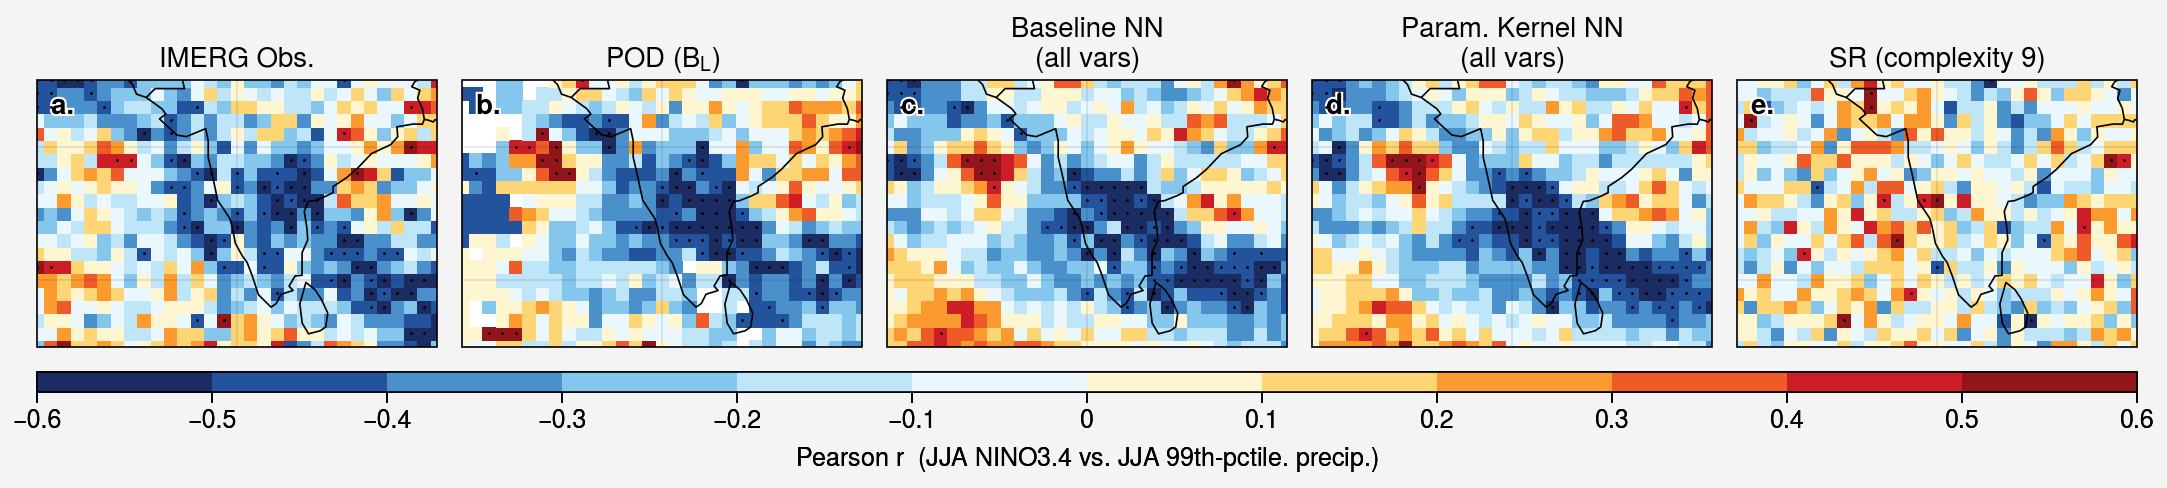

In [32]:
# 5-panel map: Pearson r between JJA NINO3.4 and JJA 99th-percentile precipitation
# Stippling marks grid points significant at p < 0.05 (|r| > 0.433 for n=21)
PANELS = [
    (r_imerg, p_imerg, 'IMERG Obs.'),
    (r_bl,    p_bl,    'POD ($B_L$)'),
    (r_base,  p_base,  'Baseline NN\n(all vars)'),
    (r_param, p_param, 'Param. Kernel NN\n(all vars)'),
    (r_sr,    p_sr,    'SR (complexity 9)'),
]

fig,axs = pplt.subplots(ncols=5,proj='cyl',refwidth=2)
axs.format(
    coast=True,borders=True,
    latlim=(LATRANGE[0],LATRANGE[1]),lonlim=(LONRANGE[0],LONRANGE[1]),
    latlines=10,lonlines=15,
    abc=True,abcloc='ul',abcstyle='a.')

mappable = None
for ax,(r,p,title) in zip(axs,PANELS):
    ax.format(title=title)
    if r is None:
        continue
    m = ax.pcolormesh(r.lon.values,r.lat.values,r.values,
                      cmap='ColdHot',vmin=-0.7,vmax=0.7,N=15)
    if mappable is None:
        mappable = m
    if p is not None:
        pmask = p.values < 0.05
        if pmask.any():
            lons2d,lats2d = np.meshgrid(r.lon.values,r.lat.values)
            ax.scatter(lons2d[pmask],lats2d[pmask],c='k',s=1,zorder=5,linewidths=0)

fig.colorbar(mappable,loc='b',
             label='Pearson $r$  (JJA NINO3.4 vs. JJA 99th-pctile. precip.)',
             width=0.1)
os.makedirs('../figs',exist_ok=True)
# fig.save('../figs/fig_enso.jpg')
pplt.show()